In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("processed_caltech.csv")

df.head()

,_id,userInputs,sessionID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,kWhDelivered,doneChargingTime,timezone,userID,session_duration_hours,charging_duration_hours,utilization_rate
0,5bc90cb9f9af8b0d7fe77cd2,NaN,2_39_78_362_2018-04-25 11:08:04.400812,2-39-78-362,CA-496,2,39,2018-04-25 11:08:04+00:00,2018-04-25 13:20:10+00:00,7.932,2018-04-25 13:21:10+00:00,America/Los_Angeles,NaN,2.201667,2.218333,1.007570
1,5bc90cb9f9af8b0d7fe77cd3,NaN,2_39_95_27_2018-04-25 13:45:09.617470,2-39-95-27,CA-319,2,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,10.013,2018-04-25 16:44:15+00:00,America/Los_Angeles,NaN,11.185000,2.984722,0.266850
2,5bc90cb9f9af8b0d7fe77cd4,NaN,2_39_79_380_2018-04-25 13:45:49.962001,2-39-79-380,CA-489,2,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,5.257,2018-04-25 14:51:44+00:00,America/Los_Angeles,NaN,9.315278,1.098333,0.117907
3,5bc90cb9f9af8b0d7fe77cd5,NaN,2_39_79_379_2018-04-25 14:37:06.460772,2-39-79-379,CA-327,2,39,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,5.177,2018-04-25 16:05:22+00:00,America/Los_Angeles,NaN,9.307778,1.471111,0.158052
4,5bc90cb9f9af8b0d7fe77cd6,NaN,2_39_79_381_2018-04-25 14:40:33.638896,2-39-79-381,CA-490,2,39,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,10.119,2018-04-25 17:40:30+00:00,America/Los_Angeles,NaN,8.377222,2.998889,0.357981


In [3]:
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['disconnectTime'] = pd.to_datetime(df['disconnectTime'])
df['doneChargingTime'] = pd.to_datetime(df['doneChargingTime'])

In [4]:
df['hour'] = df['connectionTime'].dt.hour
df['day_of_week'] = df['connectionTime'].dt.dayofweek
df['month'] = df['connectionTime'].dt.month
df['date'] = df['connectionTime'].dt.date

In [5]:
BASE_TARIFF = 15

df['revenue'] = (
    df['kWhDelivered']
    * BASE_TARIFF
)

In [6]:
df[['kWhDelivered','revenue']].head()

,kWhDelivered,revenue
0,7.932,118.980
1,10.013,150.195
2,5.257,78.855
3,5.177,77.655
4,10.119,151.785


In [7]:
df['demand_level'] = 'Medium'

df.loc[
    df['hour'].between(15,17),
    'demand_level'
] = 'High'

df.loc[
    df['hour'].between(6,12),
    'demand_level'
] = 'Low'

In [8]:
df[['hour','demand_level']].head(20)

,hour,demand_level
0,11,Low
1,13,Medium
2,13,Medium
3,14,Medium
4,14,Medium
5,14,Medium
6,14,Medium
7,14,Medium
8,15,High
9,15,High


In [9]:
df['utilization_category'] = pd.cut(
    df['utilization_rate'],
    bins=[0,0.3,0.8,1.5],
    labels=['Low','Medium','High']
)

In [10]:
df['utilization_category'].value_counts()

utilization_category
High      7626
Medium    4556
Low       2790
Name: count, dtype: int64

In [11]:
hourly_df = (
    df.groupby(
        ['date','hour']
    )
    .size()
    .reset_index(name='demand')
)

In [12]:
hourly_df.head()

,date,hour,demand
0,2018-04-25,11,1
1,2018-04-25,13,2
2,2018-04-25,14,5
3,2018-04-25,15,15
4,2018-04-25,16,8


In [13]:
hourly_df.shape

(3988, 3)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("processed_caltech.csv")

In [3]:
df.head()

,_id,userInputs,sessionID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,kWhDelivered,doneChargingTime,timezone,userID,session_duration_hours,charging_duration_hours,utilization_rate
0,5bc90cb9f9af8b0d7fe77cd2,NaN,2_39_78_362_2018-04-25 11:08:04.400812,2-39-78-362,CA-496,2,39,2018-04-25 11:08:04+00:00,2018-04-25 13:20:10+00:00,7.932,2018-04-25 13:21:10+00:00,America/Los_Angeles,NaN,2.201667,2.218333,1.007570
1,5bc90cb9f9af8b0d7fe77cd3,NaN,2_39_95_27_2018-04-25 13:45:09.617470,2-39-95-27,CA-319,2,39,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,10.013,2018-04-25 16:44:15+00:00,America/Los_Angeles,NaN,11.185000,2.984722,0.266850
2,5bc90cb9f9af8b0d7fe77cd4,NaN,2_39_79_380_2018-04-25 13:45:49.962001,2-39-79-380,CA-489,2,39,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,5.257,2018-04-25 14:51:44+00:00,America/Los_Angeles,NaN,9.315278,1.098333,0.117907
3,5bc90cb9f9af8b0d7fe77cd5,NaN,2_39_79_379_2018-04-25 14:37:06.460772,2-39-79-379,CA-327,2,39,2018-04-25 14:37:06+00:00,2018-04-25 23:55:34+00:00,5.177,2018-04-25 16:05:22+00:00,America/Los_Angeles,NaN,9.307778,1.471111,0.158052
4,5bc90cb9f9af8b0d7fe77cd6,NaN,2_39_79_381_2018-04-25 14:40:33.638896,2-39-79-381,CA-490,2,39,2018-04-25 14:40:34+00:00,2018-04-25 23:03:12+00:00,10.119,2018-04-25 17:40:30+00:00,America/Los_Angeles,NaN,8.377222,2.998889,0.357981


In [4]:
BASE_PRICE = 15

df['revenue_per_session'] = (
    df['kWhDelivered']
    * BASE_PRICE
)

df['revenue_per_session'].describe()

count    14974.000000
mean       135.222293
std        105.944521
min          7.515000
25%         60.270000
50%        111.750000
75%        198.075000
max       1040.595000
Name: revenue_per_session, dtype: float64

In [5]:
print(df.columns.tolist())

['_id', 'userInputs', 'sessionID', 'stationID', 'spaceID', 'siteID', 'clusterID', 'connectionTime', 'disconnectTime', 'kWhDelivered', 'doneChargingTime', 'timezone', 'userID', 'session_duration_hours', 'charging_duration_hours', 'utilization_rate', 'revenue_per_session']


In [6]:
ENERGY_COST_PER_KWH = 8

df['energy_cost'] = (
    df['kWhDelivered']
    * ENERGY_COST_PER_KWH
)

df['profit_per_session'] = (
    df['revenue_per_session']
    - df['energy_cost']
)

df[
    [
        'kWhDelivered',
        'revenue_per_session',
        'energy_cost',
        'profit_per_session'
    ]
].head()

,kWhDelivered,revenue_per_session,energy_cost,profit_per_session
0,7.932,118.980,63.456,55.524
1,10.013,150.195,80.104,70.091
2,5.257,78.855,42.056,36.799
3,5.177,77.655,41.416,36.239
4,10.119,151.785,80.952,70.833


In [7]:
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

df['hour'] = df['connectionTime'].dt.hour

df['date'] = df['connectionTime'].dt.date

df[['hour','date']].head()

,hour,date
0,11,2018-04-25
1,13,2018-04-25
2,13,2018-04-25
3,14,2018-04-25
4,14,2018-04-25


In [8]:
queue_df = (
    df.groupby(['date','hour'])
    .size()
    .reset_index(name='queue_length_proxy')
)

queue_df.head()

,date,hour,queue_length_proxy
0,2018-04-25,11,1
1,2018-04-25,13,2
2,2018-04-25,14,5
3,2018-04-25,15,15
4,2018-04-25,16,8


In [9]:
TOTAL_STATIONS = df['stationID'].nunique()

queue_df['occupancy_density'] = (
    queue_df['queue_length_proxy']
    / TOTAL_STATIONS
)

queue_df.head()

,date,hour,queue_length_proxy,occupancy_density
0,2018-04-25,11,1,0.018519
1,2018-04-25,13,2,0.037037
2,2018-04-25,14,5,0.092593
3,2018-04-25,15,15,0.277778
4,2018-04-25,16,8,0.148148


<Axes: title={'center': 'Monthly Charging Demand'}, xlabel='connectionTime'>

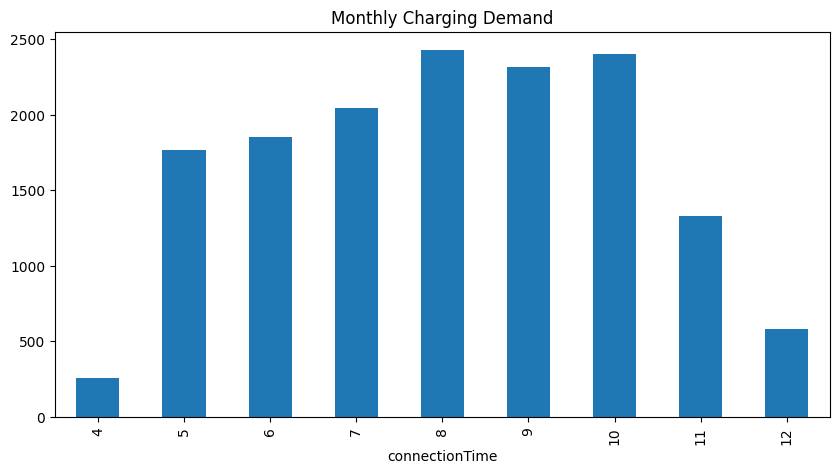

In [10]:
monthly_demand = (
    df.groupby(
        df['connectionTime'].dt.month
    )
    .size()
)

monthly_demand.plot(
    kind='bar',
    figsize=(10,5),
    title='Monthly Charging Demand'
)